In [40]:
# Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [41]:
# Upload Dataset

df = pd.read_excel('default of credit card clients.xls', header=1)

In [42]:
# Data Exploration

df.head()
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.info()
df.describe()
print("Is Null:")
df.isnull().sum()
print("Duplicates:")
df.duplicated().sum()

Rows   : 30000
Columns: 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 

np.int64(0)

In [43]:
# Check for outliers / undocumented values

print('EDUCATION value counts:')
print(df['EDUCATION'].value_counts().sort_index())
print('MARRIAGE value counts:')
print(df['MARRIAGE'].value_counts().sort_index())

EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [44]:
# Fix the issues

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df = df.rename(columns={'PAY_0': 'PAY_1'})
df = df.rename(columns={'default payment next month': 'DEFAULT'})

<Figure size 640x480 with 0 Axes>

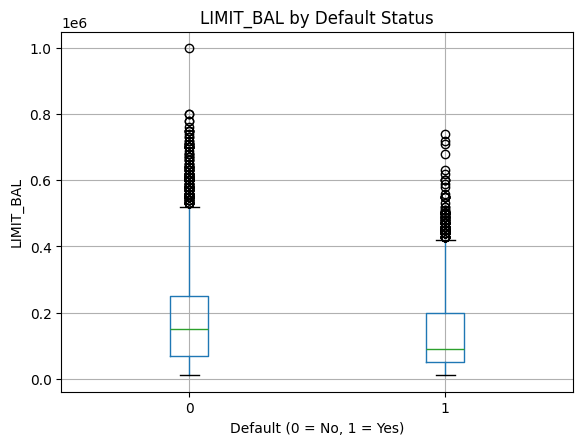

<Figure size 640x480 with 0 Axes>

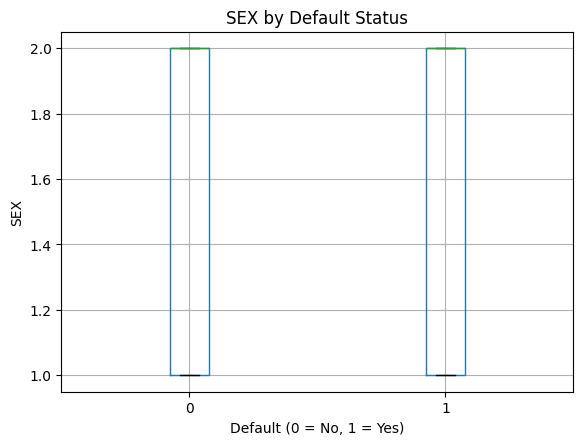

<Figure size 640x480 with 0 Axes>

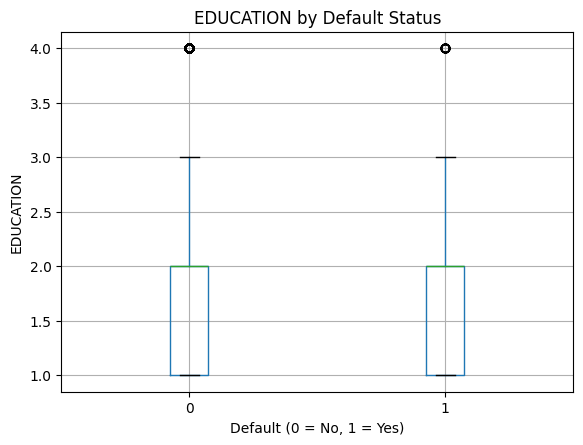

<Figure size 640x480 with 0 Axes>

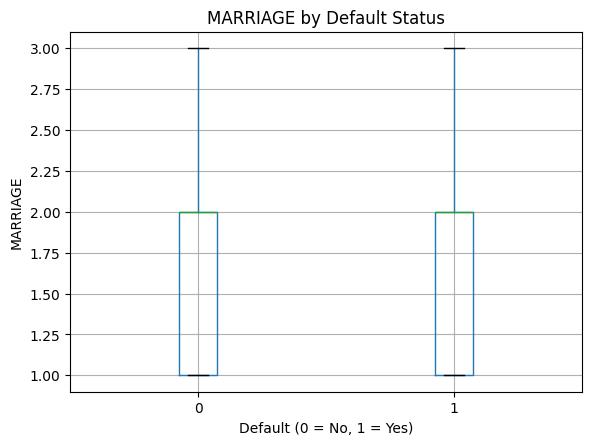

<Figure size 640x480 with 0 Axes>

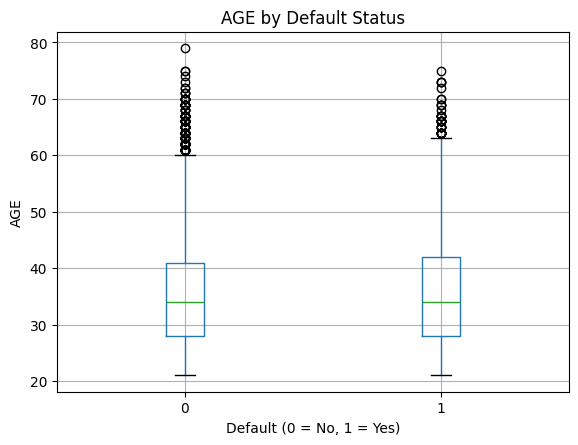

<Figure size 640x480 with 0 Axes>

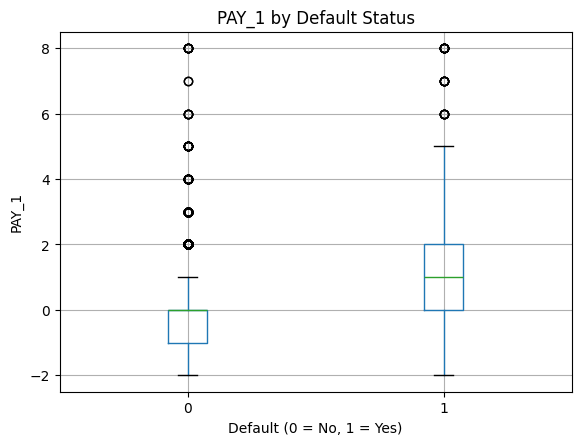

<Figure size 640x480 with 0 Axes>

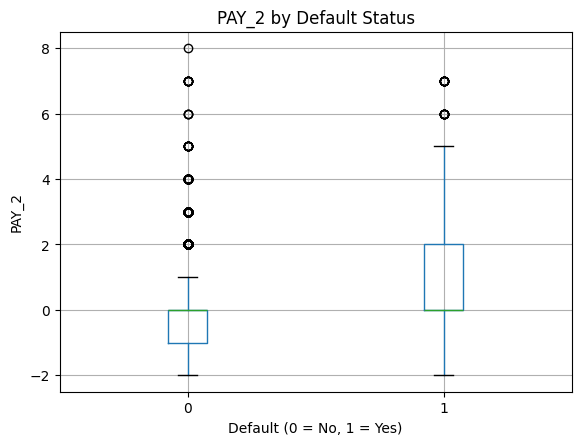

<Figure size 640x480 with 0 Axes>

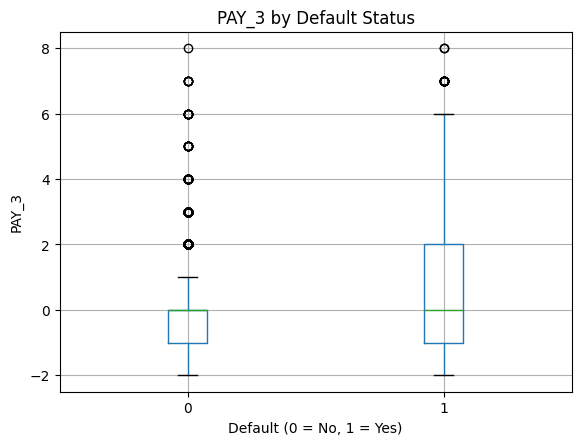

<Figure size 640x480 with 0 Axes>

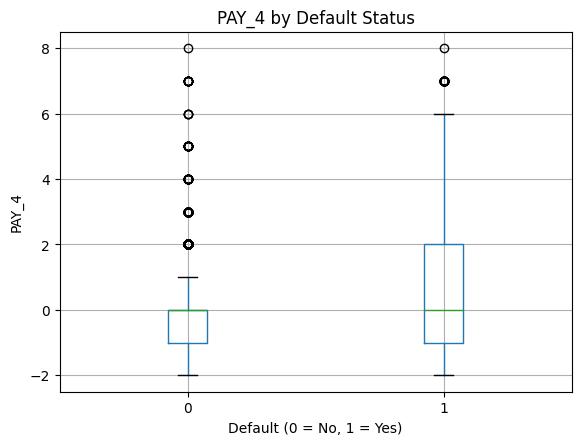

<Figure size 640x480 with 0 Axes>

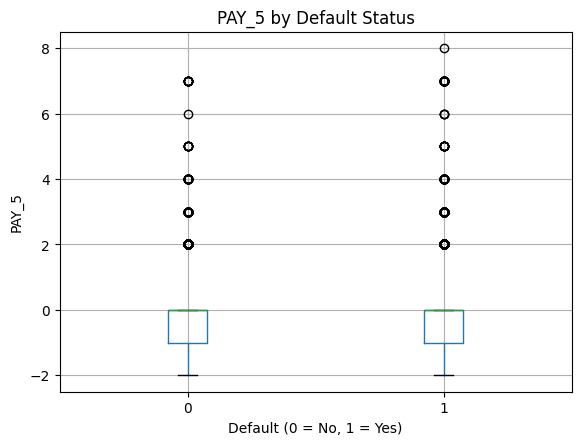

<Figure size 640x480 with 0 Axes>

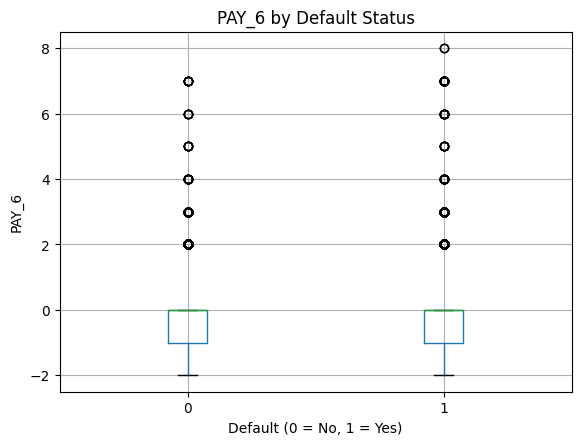

<Figure size 640x480 with 0 Axes>

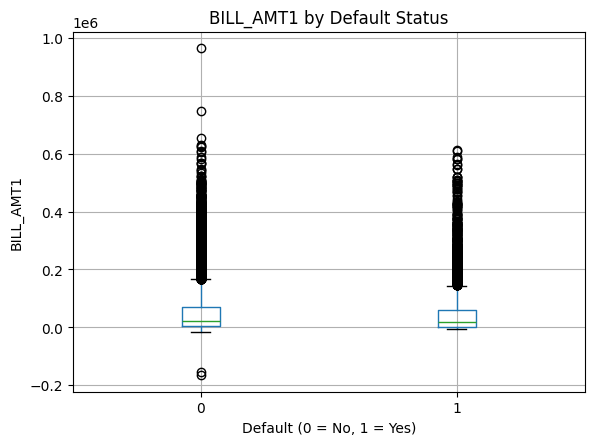

<Figure size 640x480 with 0 Axes>

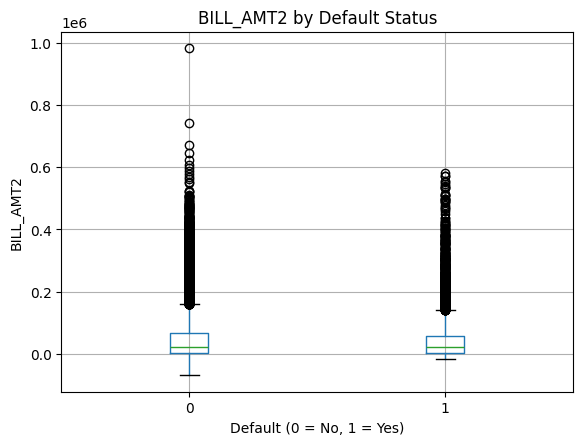

<Figure size 640x480 with 0 Axes>

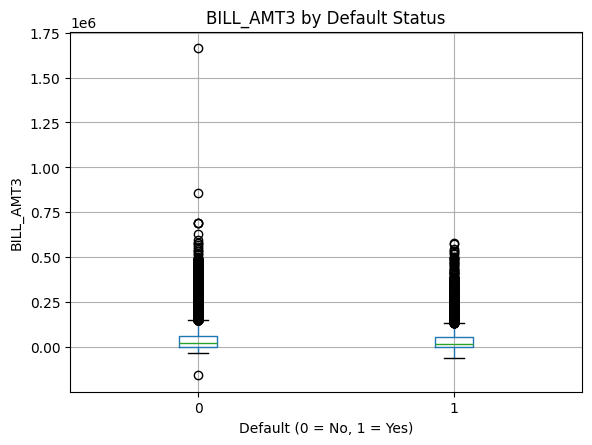

<Figure size 640x480 with 0 Axes>

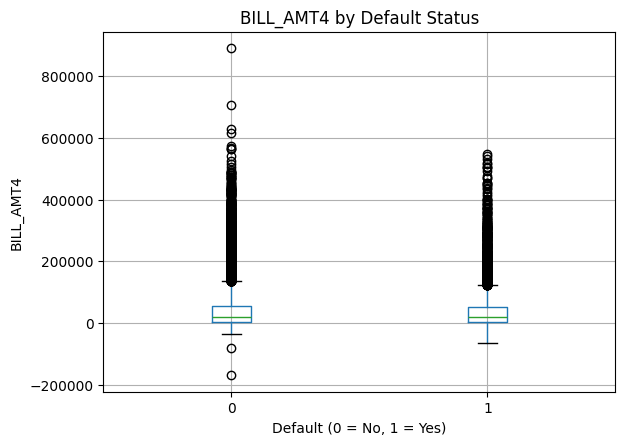

<Figure size 640x480 with 0 Axes>

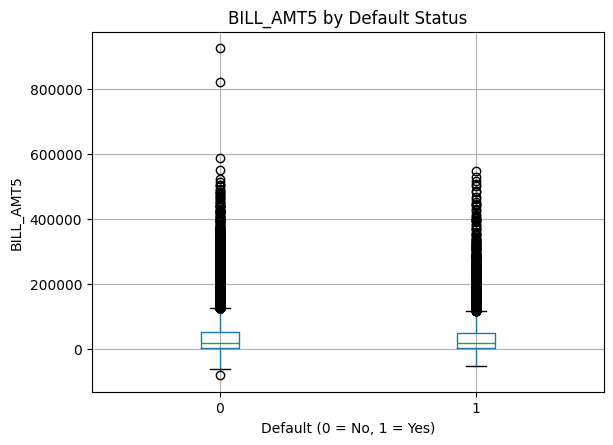

<Figure size 640x480 with 0 Axes>

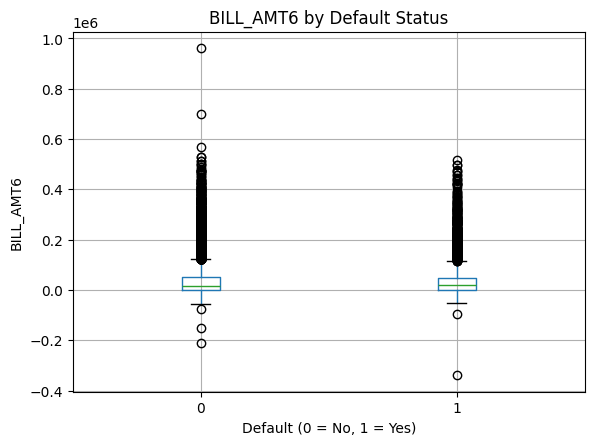

<Figure size 640x480 with 0 Axes>

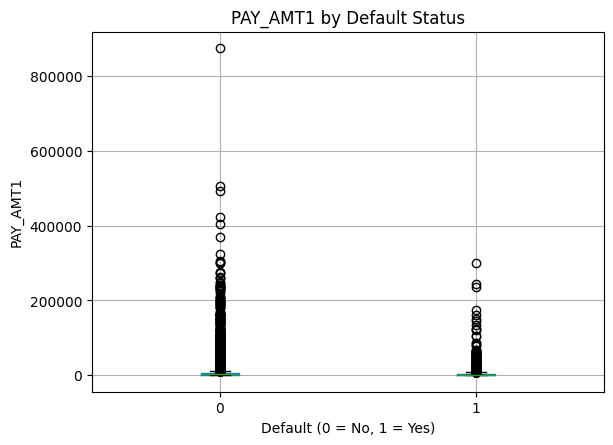

<Figure size 640x480 with 0 Axes>

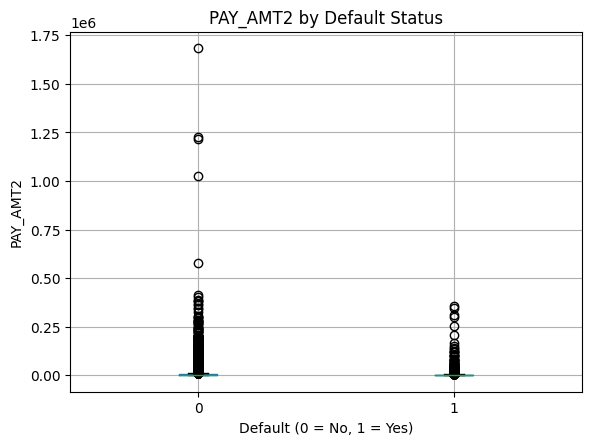

<Figure size 640x480 with 0 Axes>

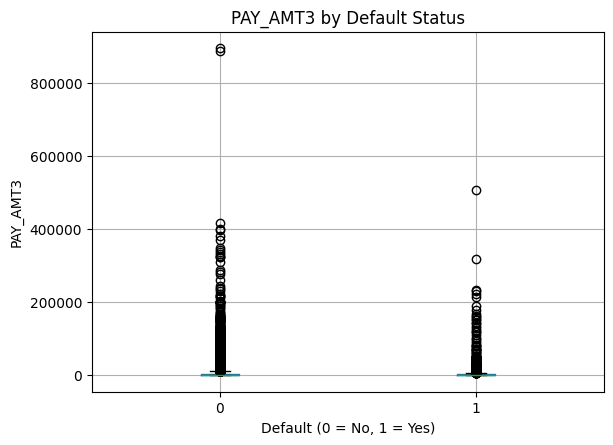

<Figure size 640x480 with 0 Axes>

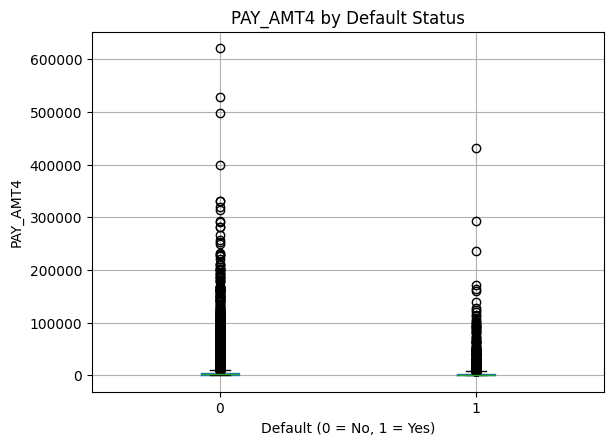

<Figure size 640x480 with 0 Axes>

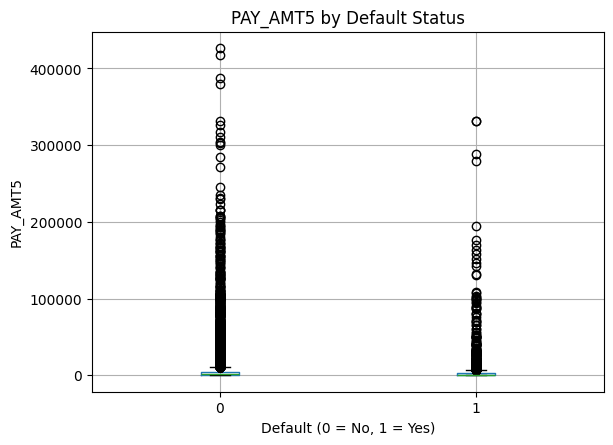

<Figure size 640x480 with 0 Axes>

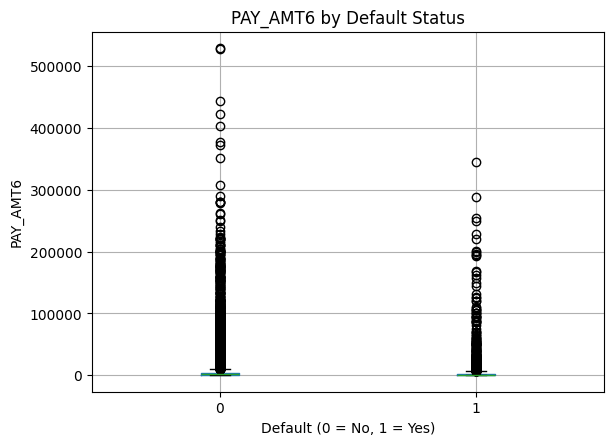

In [45]:
# Run a box plot for each feature column to check for correlation with a binary output

feature_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
                'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for col in feature_cols:
    plt.figure()
    df.boxplot(column=col, by='DEFAULT')
    plt.title(f'{col} by Default Status')
    plt.suptitle('')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()

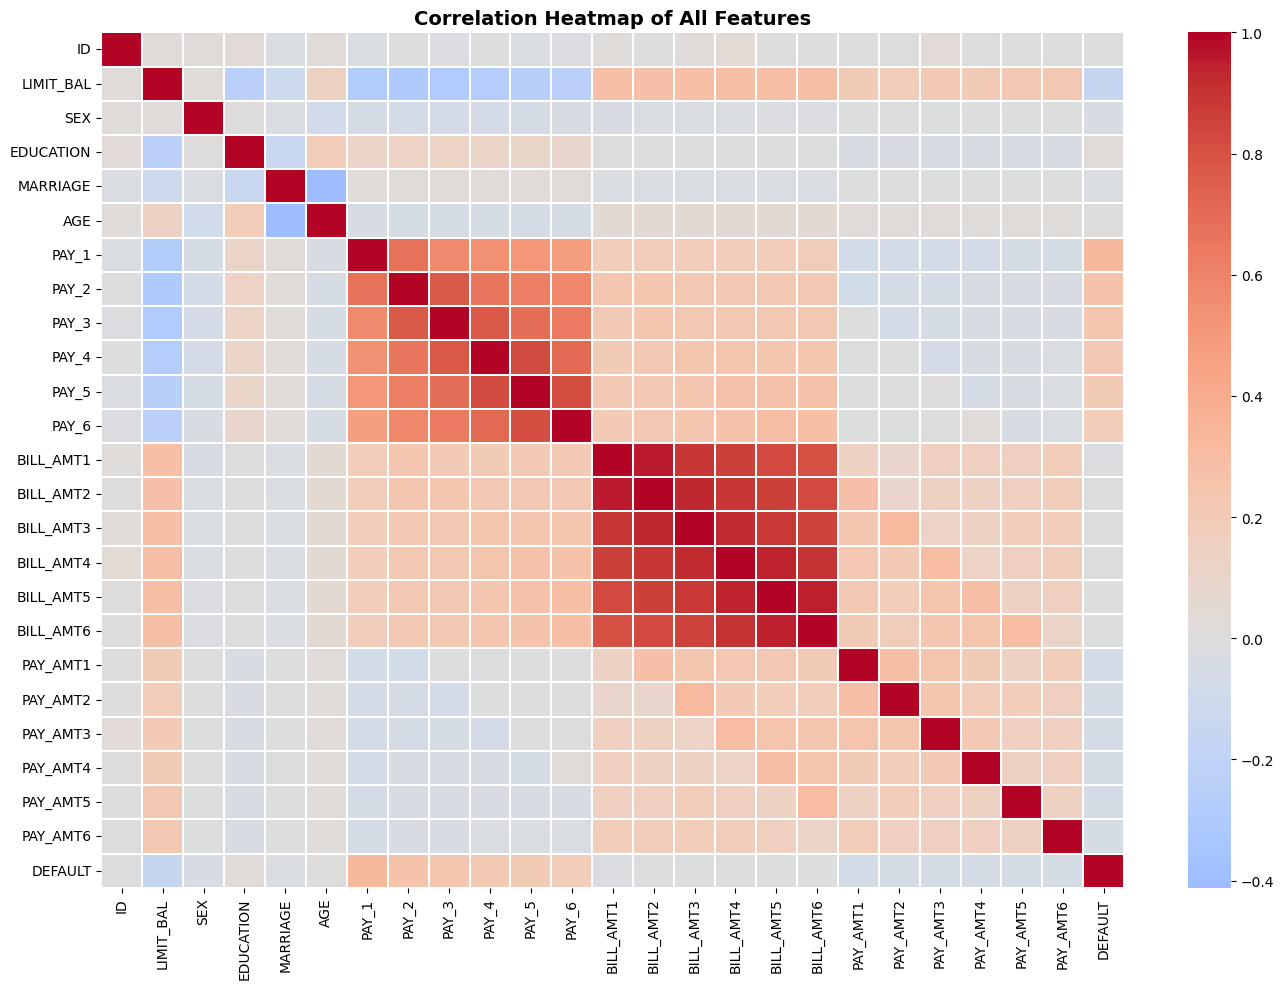

In [46]:
# Correlation Heat Map

corr = df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax)
ax.set_title('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
# Set X and Y Variables

X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']

In [48]:
# Train and Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [49]:
# Make sure splitting them didnt mess up the class balance

print(f'Default rate in full data  : {y.mean():.4f}')
print(f'Default rate in train set  : {y_train.mean():.4f}')
print(f'Default rate in test set   : {y_test.mean():.4f}')

Default rate in full data  : 0.2212
Default rate in train set  : 0.2200
Default rate in test set   : 0.2258


In [50]:
# Import the models and evaluation tools
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [51]:
# Drop the ID column (not useful for prediction)
X_train = X_train.drop(columns=['ID'])
X_test = X_test.drop(columns=['ID'])

In [56]:
# Try a Decision Tree with a max depth to prevent overfitting
dt = DecisionTreeClassifier(max_depth=5, random_state=67)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

print("=== Decision Tree (max_depth=5) ===")
print(f"Accuracy  : {accuracy_score(y_test, dt_preds):.4f}")
print(f"Precision : {precision_score(y_test, dt_preds):.4f}")
print(f"Recall    : {recall_score(y_test, dt_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, dt_preds):.4f}")

=== Decision Tree (max_depth=5) ===
Accuracy  : 0.8193
Precision : 0.6927
Recall    : 0.3594
F1-Score  : 0.4733


In [57]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Naive Bayes on scaled data
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_preds = nb.predict(X_test_scaled)

print(" Naive Bayes ")
print(f"Accuracy  : {accuracy_score(y_test, nb_preds):.4f}")
print(f"Precision : {precision_score(y_test, nb_preds):.4f}")
print(f"Recall    : {recall_score(y_test, nb_preds):.4f}")
print(f"F1-Score  : {f1_score(y_test, nb_preds):.4f}")

 Naive Bayes 
Accuracy  : 0.7002
Precision : 0.4031
Recall    : 0.6819
F1-Score  : 0.5067


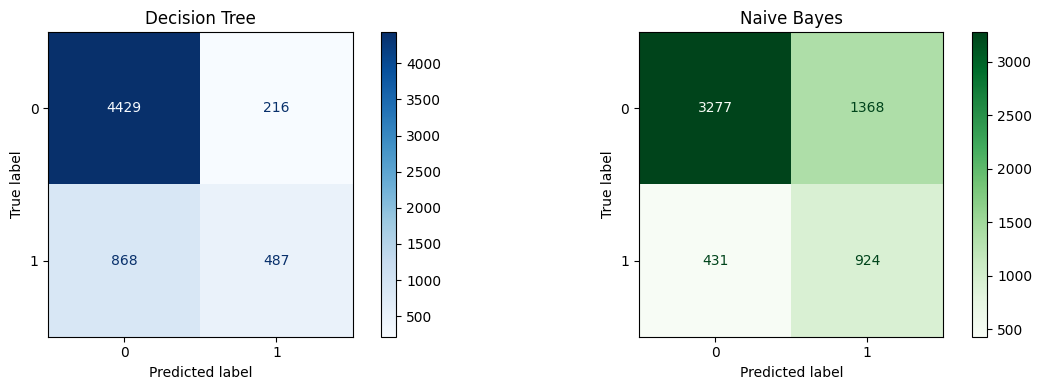

In [58]:
# Confusion Matrix - Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, dt_preds, ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(y_test, nb_preds, ax=axes[1], cmap='Greens')
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

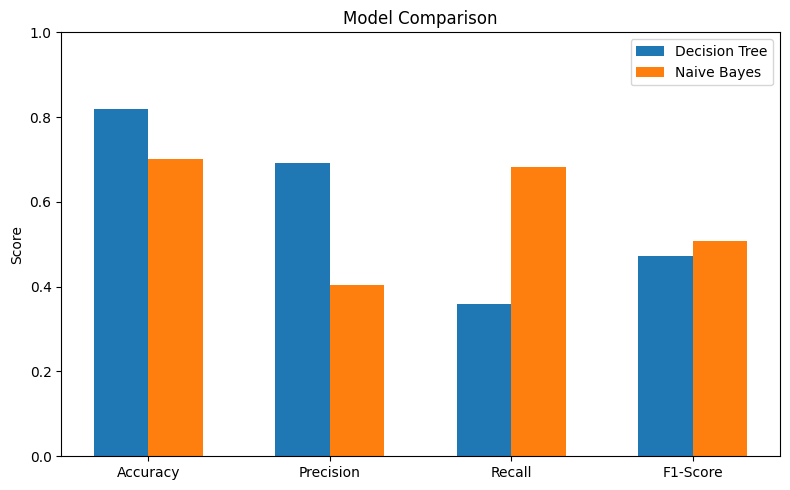

In [59]:
# Bar chart comparing the two models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

dt_scores = [
    accuracy_score(y_test, dt_preds),
    precision_score(y_test, dt_preds),
    recall_score(y_test, dt_preds),
    f1_score(y_test, dt_preds)
]

nb_scores = [
    accuracy_score(y_test, nb_preds),
    precision_score(y_test, nb_preds),
    recall_score(y_test, nb_preds),
    f1_score(y_test, nb_preds)
]

x = np.arange(len(metrics))
width = 0.3

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, dt_scores, width, label='Decision Tree')
plt.bar(x + width/2, nb_scores, width, label='Naive Bayes')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()